<a href="https://colab.research.google.com/github/huiying8888/data-analytics/blob/main/Capstone/Insurance_Claims_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load Data

In [45]:
import pandas as pd
import numpy as np

# Sourced from Healthcare.gov transparency in coverage PUFs, 2023 - https://data.healthcare.gov/datasets?fulltext=transparency%20in%20coverage
url = "https://github.com/huiying8888/data-analytics/raw/refs/heads/main/Capstone/transparency_in_coverage_PUF_2023.xlsx"
df = pd.read_excel(url, sheet_name="Transparency 2023 - Ind QHP", header= 2)

Cleaning Data

In [46]:
# Replace special values
df = df.replace(["*", "**", "***", "N/A"], np.nan)

# These are the columns we're interested in and need to clean empty rows from
cols = [
"Plan_Number_Claims_Received",
"Plan_Number_Claims_Denied",
"Average Monthly Enrollment",
"Average Monthly Disenrollment"
]

# Convert the rows of our columns from string to number, if any data fails to do this (such as remaining '***'), make it NaN
for col in cols:
  df[col] = pd.to_numeric(df[col], errors="coerce")

# Drop missing values - Missing values mean the plan will not be renewed with CMS
df = df.dropna(subset=cols)

# Filter out data that would cause a divide by zero
df = df[df["Plan_Number_Claims_Received"] > 0]
df = df[df["Average Monthly Enrollment"] > 0]

# Create variables
df["denial_rate"] = df["Plan_Number_Claims_Denied"] / df["Plan_Number_Claims_Received"]

df["disenrollment_rate"] = df["Average Monthly Disenrollment"] / df["Average Monthly Enrollment"]

# Check result
df[["denial_rate", "disenrollment_rate"]].head()



,denial_rate,disenrollment_rate
0,0.229973,0.113255
1,0.261248,0.110005
2,0.225548,0.132871
3,0.265802,0.124562
9,0.070346,0.170940


Summary Function

In [47]:
def summarize_rates(data):
  return data[["denial_rate", "disenrollment_rate"]].describe()

summarize_rates(df)


,denial_rate,disenrollment_rate
count,1811.000000,1811.000000
mean,0.166268,0.153469
std,0.099489,0.050633
min,0.012646,0.057845
25%,0.098178,0.118952
50%,0.147314,0.143385
75%,0.209622,0.174568
max,0.534794,0.526316


Overall Deial Rate

In [48]:
overall_denial = df["Plan_Number_Claims_Denied"].sum() / df["Plan_Number_Claims_Received"].sum()
overall_denial


np.float64(0.1688733893925872)

Variation Across Plans

In [49]:
df["denial_rate"].describe()

,denial_rate
count,1811.000000
mean,0.166268
std,0.099489
min,0.012646
25%,0.098178
50%,0.147314
75%,0.209622
max,0.534794


In [50]:
# Denial rate per company (issuer)
df.groupby("Issuer_Name")["denial_rate"].mean().sort_values()

,denial_rate
Issuer_Name,
"Oscar Health Plan of North Carolina, Inc",0.023595
Oscar Insurance Corporation of Ohio,0.030516
Group Hospitalization and Medical Services Inc.,0.032933
Oscar Health Plan of Georgia,0.034554
Oscar Buckeye State Insurance Corp.,0.035047
...,...
Ambetter of Magnolia Inc.,0.413626
Ambetter of North Carolina Inc.,0.429491
Anthem Ins Companies Inc(Anthem BCBS),0.430245


Top 10 denial insurance companies

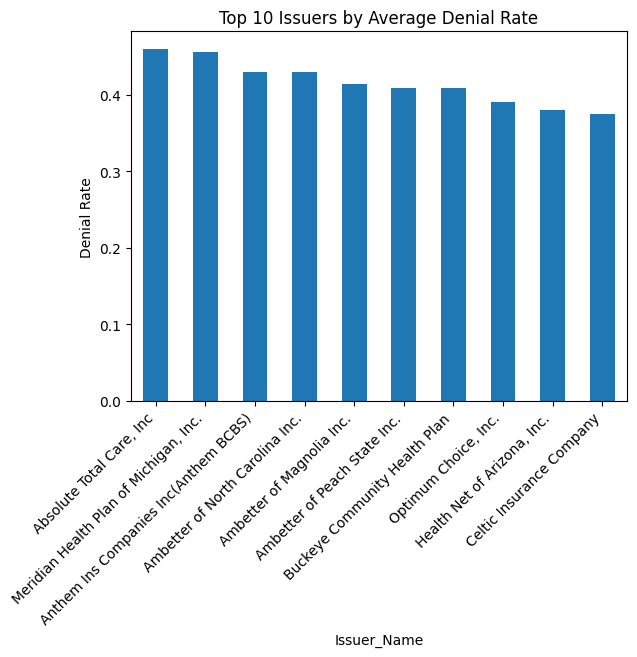

In [51]:
import matplotlib.pyplot as plt

top_10 = df.groupby("Issuer_Name")["denial_rate"].mean().sort_values(ascending=False).head(10)

top_10.plot(kind="bar")
plt.title("Top 10 Issuers by Average Denial Rate")
plt.ylabel("Denial Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

bottom 10

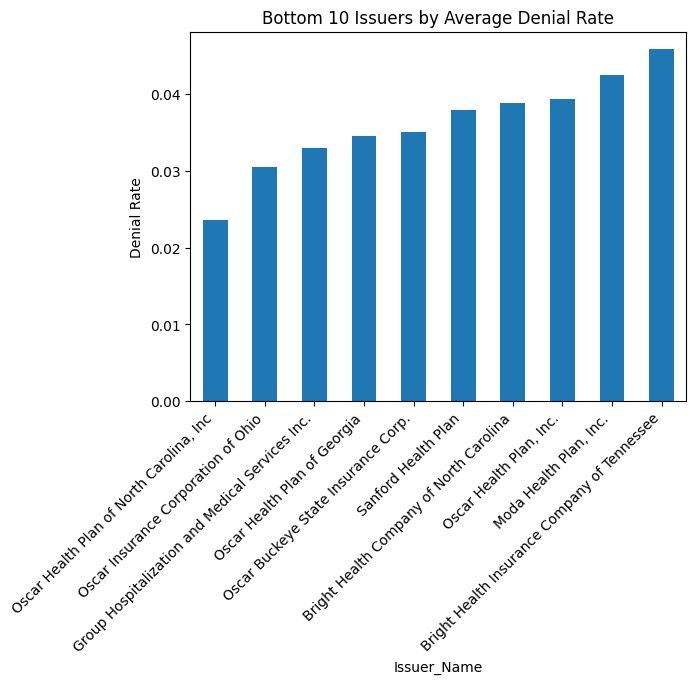

In [52]:
bottom10 = df.groupby("Issuer_Name")["denial_rate"].mean().sort_values().head(10)

bottom10.plot(kind="bar")
plt.title("Bottom 10 Issuers by Average Denial Rate")
plt.ylabel("Denial Rate")
plt.xticks(rotation=45, ha="right")
plt.show()

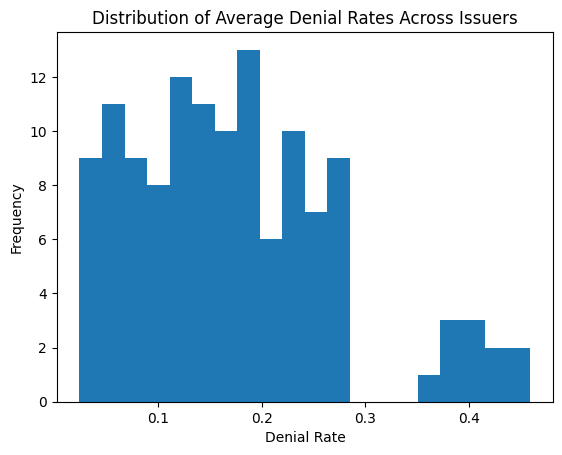

In [53]:
# Show a bellcurve for denial rate by company

df.groupby("Issuer_Name")["denial_rate"].mean().plot(kind="hist", bins=20)
plt.title("Distribution of Average Denial Rates Across Issuers")
plt.xlabel("Denial Rate")
plt.show()


Denial Rate by Metal level

In [54]:
df.groupby("Metal_Level")["denial_rate"].mean().sort_values()

,denial_rate
Metal_Level,
Platinum,0.112946
Bronze Expanded,0.150836
Catastrophic,0.160414
Silver,0.168918
Gold,0.180473
Bronze,0.203496


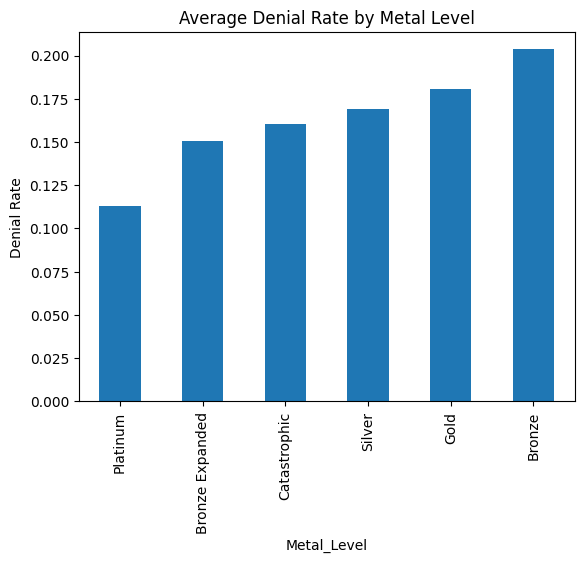

In [55]:
df.groupby("Metal_Level")["denial_rate"].mean().sort_values().plot(kind="bar")
plt.title("Average Denial Rate by Metal Level")
plt.ylabel("Denial Rate")
plt.show()

Relationship scatter plots

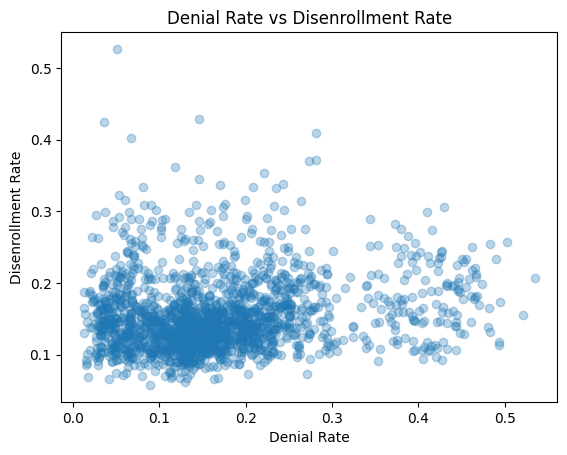

In [56]:
plt.scatter(df["denial_rate"], df["disenrollment_rate"], alpha=0.3)
plt.xlabel("Denial Rate")
plt.ylabel("Disenrollment Rate")
plt.title("Denial Rate vs Disenrollment Rate")
plt.show()

Linear Regression

In [57]:
import statsmodels.api as sm

x = df[["denial_rate"]]
x = sm.add_constant(x)
y = df["disenrollment_rate"]

model = sm.OLS(y, x).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     disenrollment_rate   R-squared:                       0.028
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     52.11
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           7.70e-13
Time:                        00:09:05   Log-Likelihood:                 2859.0
No. Observations:                1811   AIC:                            -5714.
Df Residuals:                    1809   BIC:                            -5703.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1393      0.002     60.950      

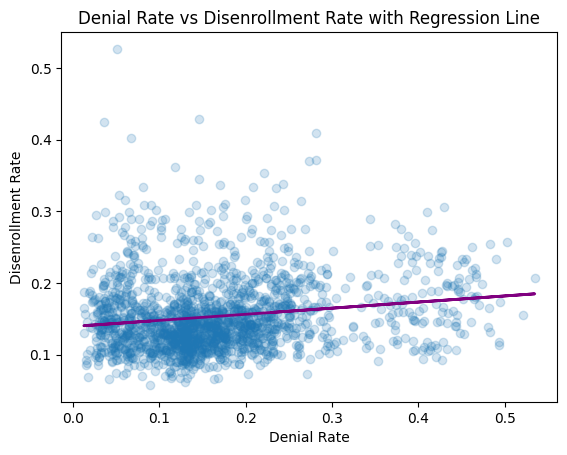

In [73]:
plt.scatter(df["denial_rate"], df["disenrollment_rate"], alpha=0.2)

plt.plot(
df["denial_rate"],
model.predict(x),
linewidth=2,
color='purple'
)

plt.xlabel("Denial Rate")
plt.ylabel("Disenrollment Rate")
plt.title("Denial Rate vs Disenrollment Rate with Regression Line")
plt.show()

The regression results show that denial rate has a positive and statistically significant association with disenrollment rate. The coefficient indicates that higher denial rates are associated with slightly higher disenrollment. However, the low R-squared value (0.028) suggests that denial rates explain only a small portion of the variation in disenrollment.

While denial rates are significantly related to disenrollment, the relationship is relatively weak. This suggests that other factors beyond claim denials likely play a larger role in influencing whether consumers leave a health plan.